<a href="https://colab.research.google.com/github/Yeabebe/explainable-ai/blob/main/heart_disease_xai_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install and Import Libraries

In [2]:
!pip install shap xgboost -q

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Feature Selection
from sklearn.feature_selection import (
    SelectKBest,
    mutual_info_classif,
    RFE
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# Explainable AI
import shap

# Notebook Settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries loaded successfully.")

Libraries loaded successfully.


Upload Dataset

In [3]:
from google.colab import files
uploaded = files.upload()

Saving heart_disease_uci.csv to heart_disease_uci.csv


Load Dataset

In [5]:
df = pd.read_csv("heart_disease_uci.csv")

print("Dataset Loaded Successfully")
print("\nShape:", df.shape)

df.head()

Dataset Loaded Successfully

Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


Dataset Overview

In [6]:
print("\nDataset Info:\n")
print(df.info())

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nStatistical Summary:\n")
print(df.describe())


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None

Missing Values:

id            0
age           0
sex           0
dataset       0
cp            0
trestbps  

Handle Missing Values

In [8]:
# Numerical columns
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical columns
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values handled.")

Missing values handled.


Encode Categorical Features

In [9]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    label_encoders[col] = le

print("Categorical variables encoded.")

df.head()

Categorical variables encoded.


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,1,0,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0,0
1,2,67,1,0,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,1,2
2,3,67,1,0,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,2,1
3,4,37,1,0,2,130.0,250.0,0,1,187.0,0,3.5,0,0.0,1,0
4,5,41,0,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0.0,1,0


Correlation Heatmap

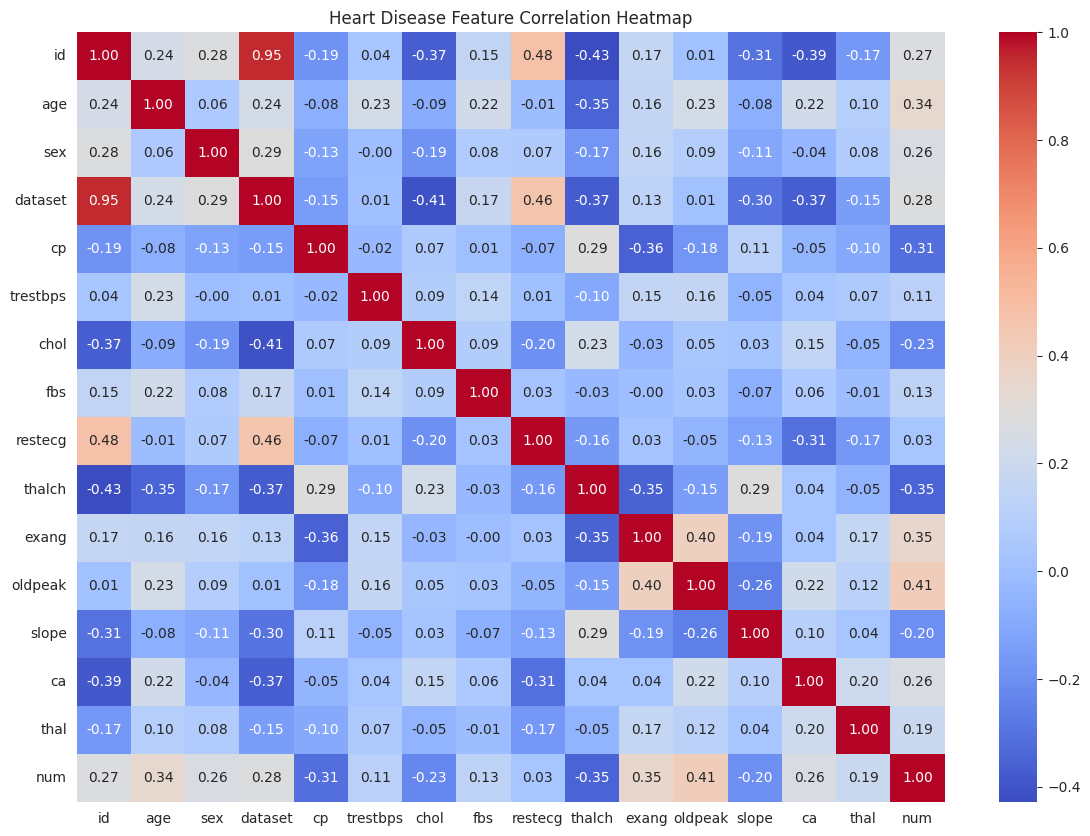

In [10]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Heart Disease Feature Correlation Heatmap")

plt.show()

Features and Target Split

In [12]:
TARGET_COLUMN = "num"

X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (920, 15)
Target Shape: (920,)


Filter Method Feature Selection

In [13]:
selector = SelectKBest(
    score_func=mutual_info_classif,
    k="all"
)

selector.fit(X, y)

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": selector.scores_
})

feature_scores = feature_scores.sort_values(
    by="Score",
    ascending=False
)

print(feature_scores)

     Feature     Score
0         id  0.410440
3    dataset  0.170357
11   oldpeak  0.164366
4         cp  0.137658
10     exang  0.098254
9     thalch  0.086767
6       chol  0.080764
1        age  0.050983
12     slope  0.046627
2        sex  0.044047
8    restecg  0.029630
13        ca  0.024164
14      thal  0.020505
5   trestbps  0.000000
7        fbs  0.000000


Wrapper Method (RFE)

In [14]:
model_rfe = LogisticRegression(max_iter=1000)

rfe = RFE(
    model_rfe,
    n_features_to_select=8
)

rfe.fit(X, y)

rfe_features = pd.DataFrame({
    "Feature": X.columns,
    "Selected": rfe.support_,
    "Ranking": rfe.ranking_
})

print(rfe_features.sort_values(by="Ranking"))

     Feature  Selected  Ranking
3    dataset      True        1
2        sex      True        1
4         cp      True        1
14      thal      True        1
13        ca      True        1
11   oldpeak      True        1
10     exang      True        1
8    restecg      True        1
12     slope     False        2
7        fbs     False        3
9     thalch     False        4
1        age     False        5
5   trestbps     False        6
0         id     False        7
6       chol     False        8


Embedded Method

In [15]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X, y)

embedded_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

embedded_importance = embedded_importance.sort_values(
    by="Importance",
    ascending=False
)

print(embedded_importance)

     Feature  Importance
0         id    0.233691
1        age    0.096899
9     thalch    0.094559
11   oldpeak    0.082119
6       chol    0.081758
5   trestbps    0.074177
4         cp    0.069126
3    dataset    0.057097
10     exang    0.043952
14      thal    0.039442
13        ca    0.033788
8    restecg    0.031595
12     slope    0.027565
7        fbs    0.018302
2        sex    0.015929


Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (736, 15)
Test Shape: (184, 15)


Feature Scaling

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


Logistic Regression

In [18]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred))

Accuracy: 0.5869565217391305

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.87      0.85        82
           1       0.49      0.62      0.55        53
           2       0.25      0.09      0.13        22
           3       0.09      0.10      0.09        21
           4       0.00      0.00      0.00         6

    accuracy                           0.59       184
   macro avg       0.33      0.33      0.32       184
weighted avg       0.55      0.59      0.56       184



Logistic Regression Confusion Matrix

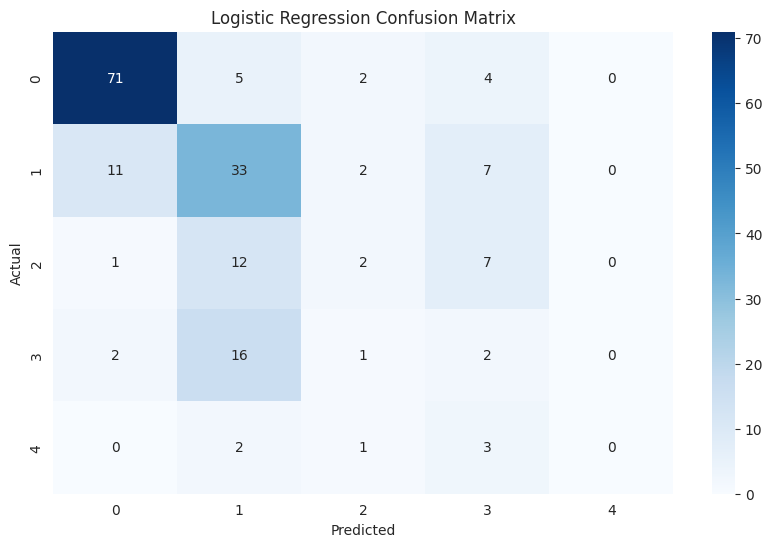

In [19]:
cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Random Forest Model

In [20]:
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

Accuracy: 0.6630434782608695

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.89      0.87        82
           1       0.65      0.77      0.71        53
           2       0.22      0.18      0.20        22
           3       0.22      0.19      0.21        21
           4       0.00      0.00      0.00         6

    accuracy                           0.66       184
   macro avg       0.39      0.41      0.40       184
weighted avg       0.62      0.66      0.64       184



Random Forest Confusion Matrix

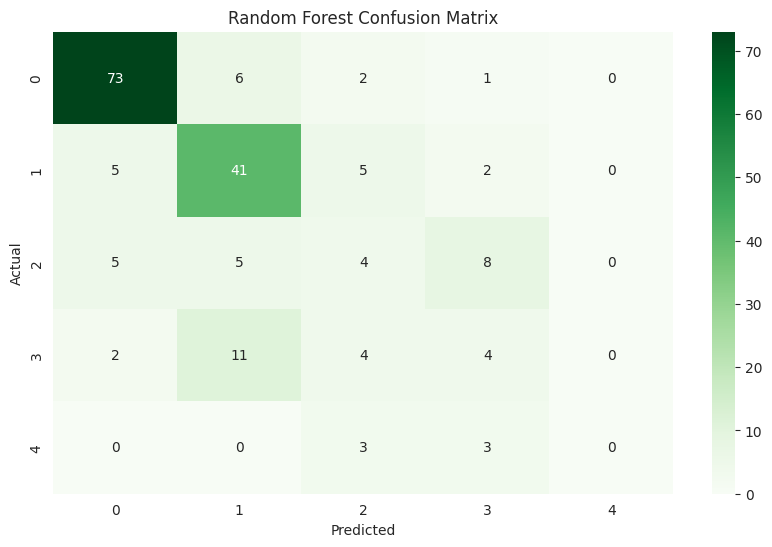

In [21]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

XGBoost Model

In [22]:
xgb_model = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, xgb_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, xgb_pred))

Accuracy: 0.6413043478260869

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.84      0.84        82
           1       0.64      0.68      0.66        53
           2       0.39      0.41      0.40        22
           3       0.22      0.19      0.21        21
           4       0.00      0.00      0.00         6

    accuracy                           0.64       184
   macro avg       0.42      0.42      0.42       184
weighted avg       0.63      0.64      0.63       184



XGBoost Confusion Matrix

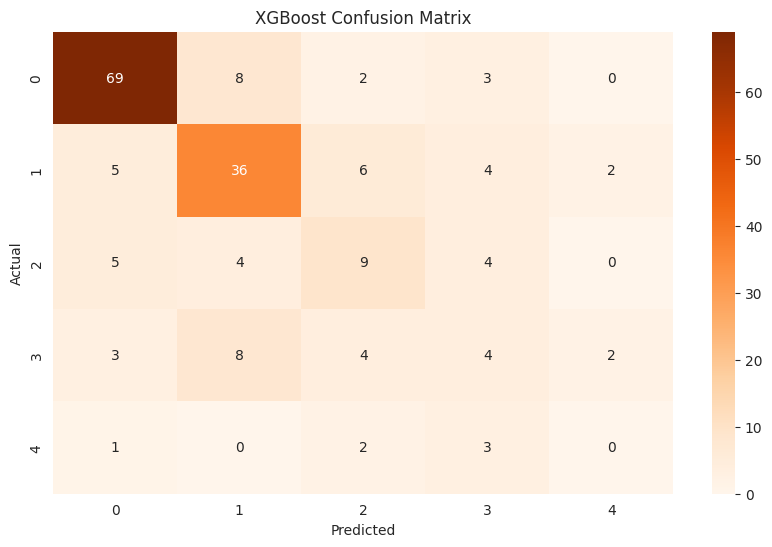

In [23]:
cm = confusion_matrix(y_test, xgb_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Model-Specific Feature Importance

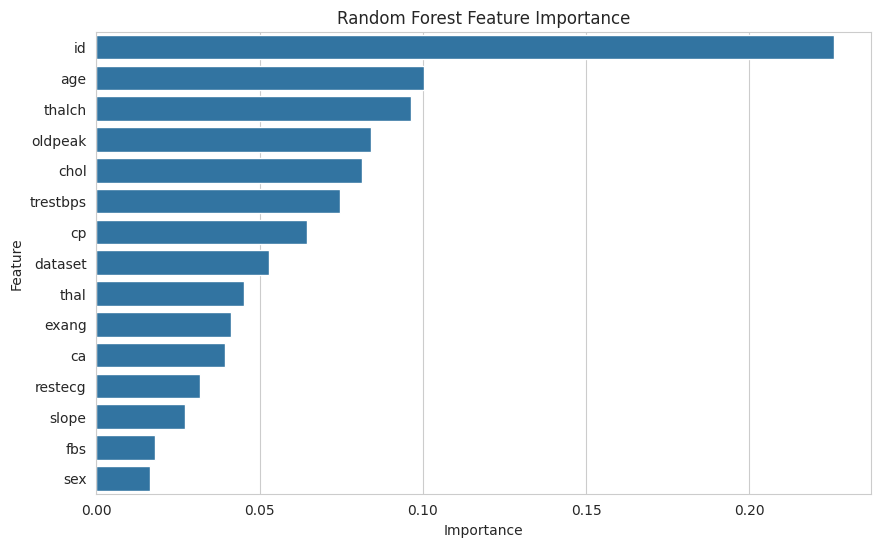

In [25]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df
)

plt.title("Random Forest Feature Importance")

plt.show()

SHAP Analysis

In [26]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

print("SHAP values generated.")

SHAP values generated.


SHAP Summary Plot

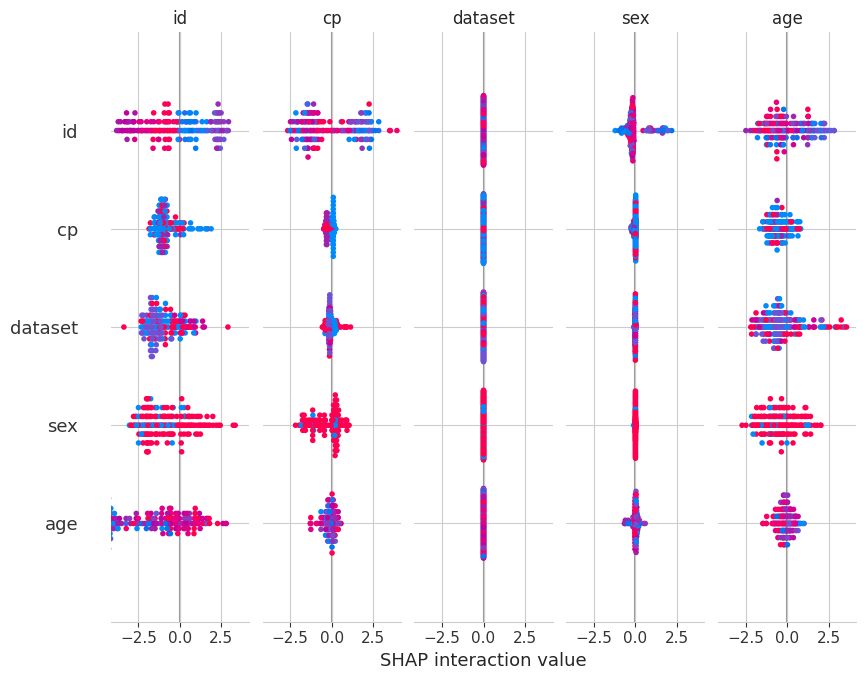

In [27]:
shap.summary_plot(
    shap_values,
    X_test
)

SHAP Bar Plot

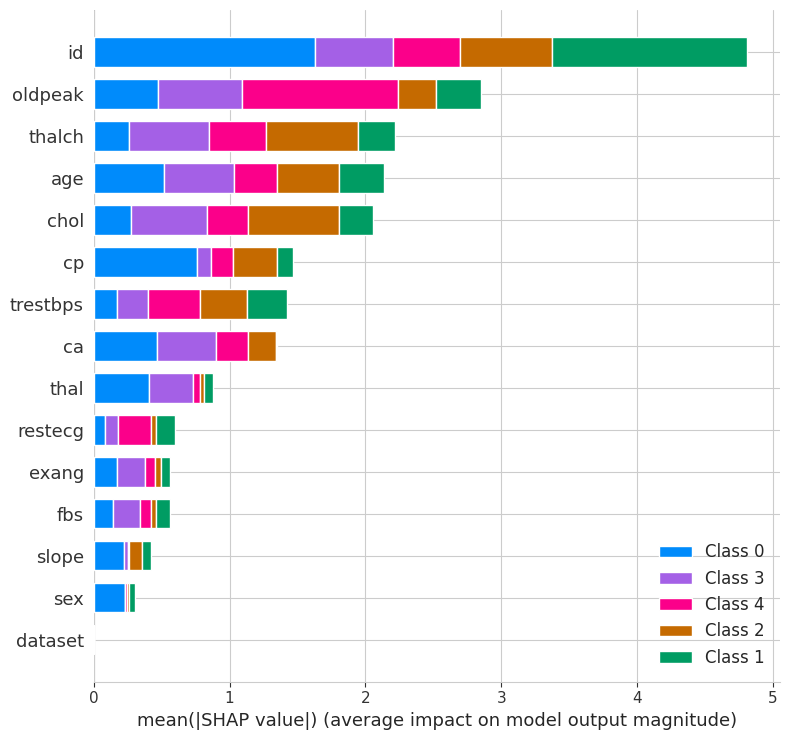

In [28]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

SHAP Dependence Plot

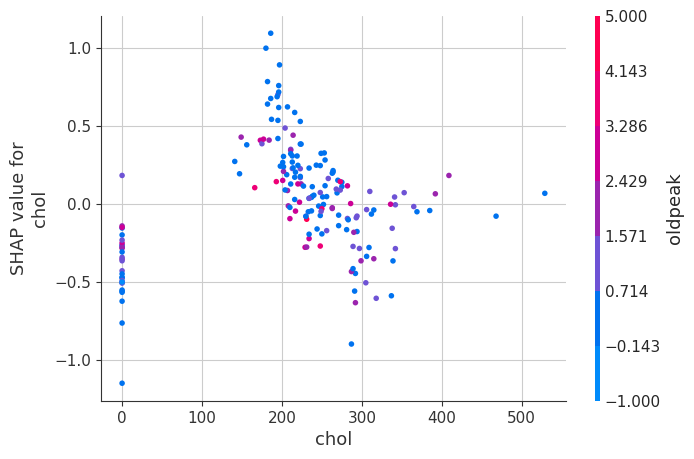

In [34]:
shap.dependence_plot(
    "chol",
    shap_values[:, :, 0], # Select SHAP values for the first class
    X_test
)

SHAP Force Plot

In [32]:
shap.initjs()

shap.force_plot(
    explainer.expected_value[0],
    shap_values[0, :, 0],
    X_test.iloc[0]
)

SHAP Waterfall Plot

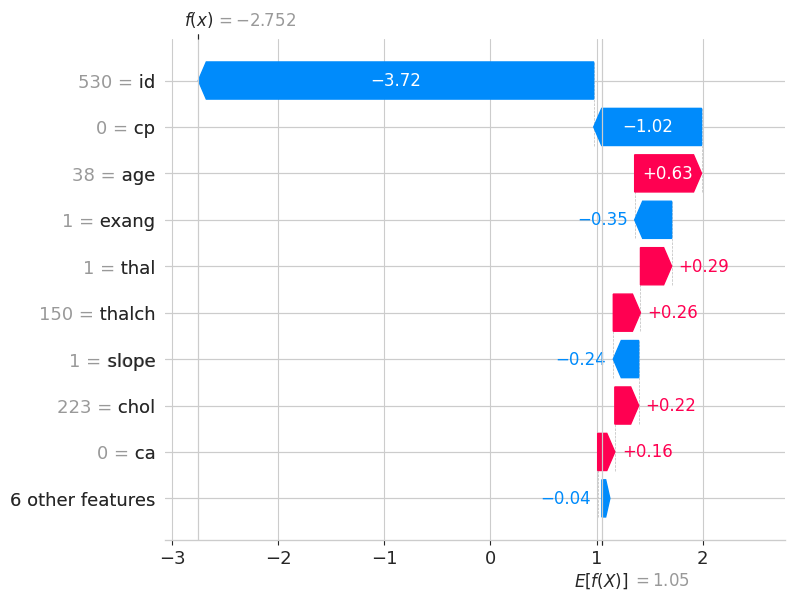

In [36]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0, :, 0], # Select SHAP values for the first instance, all features, and the first class
        base_values=explainer.expected_value[0], # Select the base value for the first class
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)

Comparative Analysis Table

In [37]:
comparison_df = pd.DataFrame({
    "Filter_Method": feature_scores["Feature"].values[:10],
    "Embedded_Method": embedded_importance["Feature"].values[:10]
})

print(comparison_df)

  Filter_Method Embedded_Method
0            id              id
1       dataset             age
2       oldpeak          thalch
3            cp         oldpeak
4         exang            chol
5        thalch        trestbps
6          chol              cp
7           age         dataset
8         slope           exang
9           sex            thal
